# Lab 2 Informal Exercises

## 1. Computational Efficiency with numpy

Based on Example 4.3 on pages 137-138 of the text, which shows you that to multiply two matrices of size $O(N)$ on a side takes $O(N^3)$ operations.
So multiplying matrices that are $N=1000$ on a side takes $O(10^9)$ operations (a ``GigaFLOP''). 

(a) Create two constant matrices $A$ and $B$, then time how long it takes to multiply the matrices to form a matrix $C$ (using the code fragment in the textbook that uses loops), for a range of $N$ (from $N = $2 to 30). 

(b) Plot this time as a function of $N$ and as a function of $N^3$.

(c) Compare this time to the time it takes numpy.dot to carry out the same operation. What do you notice?

See http://tinyurl.com/pythondot for more explanations.

N = Loop: 0.002184s | Dot: 0.003634s
N = Loop: 0.000018s | Dot: 0.000007s
N = Loop: 0.000021s | Dot: 0.000001s
N = Loop: 0.000038s | Dot: 0.000001s
N = Loop: 0.000064s | Dot: 0.000002s
N = Loop: 0.000105s | Dot: 0.000001s
N = Loop: 0.000149s | Dot: 0.000001s
N = Loop: 0.000212s | Dot: 0.000001s
N = Loop: 0.000290s | Dot: 0.000003s
N = Loop: 0.000395s | Dot: 0.000001s
N = Loop: 0.000492s | Dot: 0.000002s
N = Loop: 0.000614s | Dot: 0.000003s
N = Loop: 0.000763s | Dot: 0.000002s
N = Loop: 0.000952s | Dot: 0.000002s
N = Loop: 0.001164s | Dot: 0.000002s
N = Loop: 0.001393s | Dot: 0.000002s
N = Loop: 0.001717s | Dot: 0.000009s
N = Loop: 0.002042s | Dot: 0.000005s
N = Loop: 0.003345s | Dot: 0.000006s
N = Loop: 0.002650s | Dot: 0.000004s
N = Loop: 0.003061s | Dot: 0.000004s
N = Loop: 0.003505s | Dot: 0.000003s
N = Loop: 0.004207s | Dot: 0.000010s
N = Loop: 0.004293s | Dot: 0.000003s
N = Loop: 0.004851s | Dot: 0.000003s
N = Loop: 0.005567s | Dot: 0.000009s
N = Loop: 0.006300s | Dot: 0.000033s
N

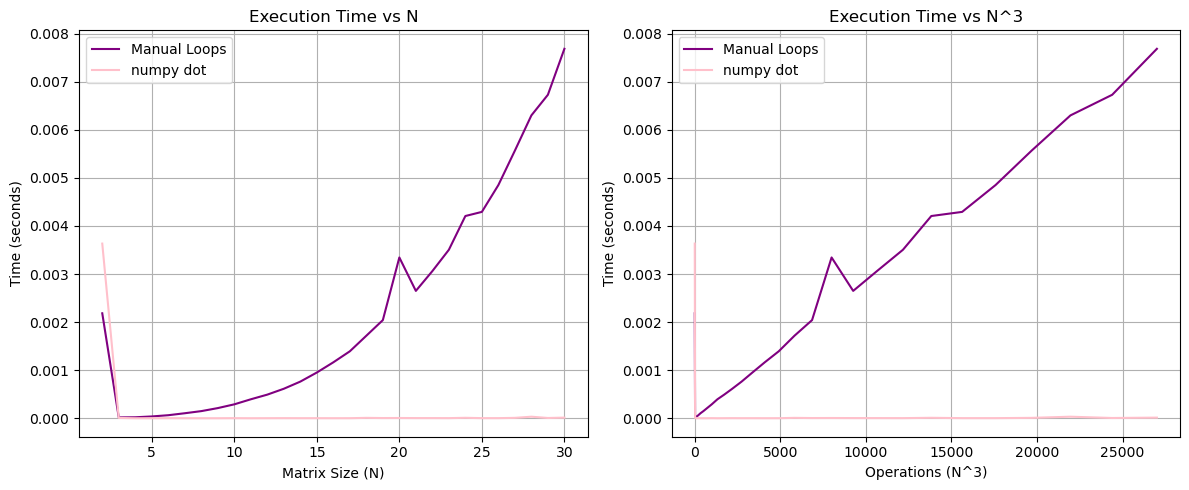

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt

size_min = 2
size_max = 30

def matrix_multiplication(A, B):
    N = len(A[0])
    C = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            for k in range(N):
                C[i,j] += A[i,k] * B[k,j]
    return C

#Create empty lists to collect individual points throughout the run
n_vals = []
loops = []
dots = []

for N in range(size_min, size_max + 1):
    n_vals.append(N)
    
    A = np.random.random((N, N))
    B = np.random.random((N, N))
    
    t_start = time.time()
    C_loop = matrix_multiplication(A, B)
    loop_duration_manual = time.time() - t_start
    loops.append(loop_duration_manual) # Keep this point
    
  
    t_start_dot = time.time()
    C_dot = np.dot(A, B)
    dot_duration_manual = time.time() - t_start_dot
    dots.append(dot_duration_manual) # Keep this point
    
    print(f"N = Loop: {loop_duration_manual:.6f}s | Dot: {dot_duration_manual:.6f}s")


n_vals = np.array(n_vals)
loops = np.array(loops)
dots = np.array(dots)


plt.figure(figsize=(12, 5))

# Plot (b) Part 1: Time vs N
plt.subplot(1, 2, 1)
plt.plot(n_vals, loops, color='purple', label="Manual Loops")
plt.plot(n_vals, dots, color='pink', label="numpy dot")
plt.xlabel("Matrix Size (N)")
plt.ylabel("Time (seconds)")
plt.title("Execution Time vs N")
plt.legend()
plt.grid(True)

# Plot (b) Part 2: Time vs N^3
plt.subplot(1, 2, 2)
plt.plot(n_vals**3, loops, color='purple', label="Manual Loops")
plt.plot(n_vals**3, dots, color='pink', label="numpy dot")
plt.xlabel("Operations (N^3)")
plt.ylabel("Time (seconds)")
plt.title("Execution Time vs N^3")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("matrix plots.png")
plt.show()


    
(c) It takes numpy.dot a lot less time to perform the same task by several orders of magnitude. Looping lacks efficiency and was what delayed my run by several minutes which demponstrates the efficiency discrepancy between modules and loops. Loops also show exponential growth in time with higher N unlike numpy which maintains the same time on average. 



In [1]:
from time import time
import timeit
import numpy as np
import matplotlib.pyplot as plt

In [2]:
size_max = 30  # the side size of the largest matrices we will multiply

In [3]:
# matrix multiplication using loops, as in Example 4.3 of the book
def manualMatrixMultiply(A, B):
    N = len(A[0])
    C = np.empty((N, N))
    for i in range(N):  
            for j in range(N):
                for k in range(N):
                    C[i, j] = A[i, k] * B[k, j]
    return C

In [6]:
# initialize NxN matrices A and B, filled with random numbers
N = 2
A = np.random.random((N, N)) 
B = np.random.random((N, N)) 

In [7]:
# matrix multiplication using numpy method
C = np.dot(A, B)

(d) Repeat parts (a) and (c) for N=100,500,1000 by submitting a job to the Teach cluster. (If you try N=1000 on Jupyter, it will probably kill your kernel. If you try N=1000 on your laptop, it will probably freeze or crash.) Remember, you need to make a .py script and test it on the cluster, then make a job submission script on the cluster!

## 2. Roundoff Error

(a) Generate an array of length $N$, filled with random numbers from a Gaussian distribution (with mean $x$ and standard deviation $\sigma$), and make a histogram (with $m$ bins) of the array values. Test this code, performing at least two sanity checks to make sure it's working properly.

[-0.77043357  1.30501969 -1.1194497  ...  0.95491444  1.28643478
 -0.0086532 ]


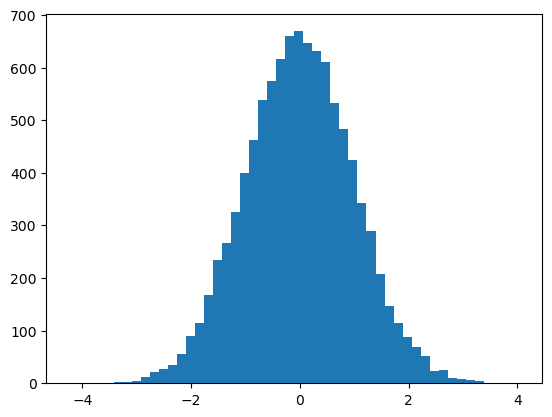

In [1]:
# Hint: np.random.normal(x, sigma, N)
# Hint: plt.hist
import numpy as np
import matplotlib.pyplot as plt

x=0
sigma= 1.0
N= 10000
m=50
myRandomArray= np.random.normal(x, sigma, N)
plt.hist(myRandomArray, m, histtype='stepfilled')
plt.savefig("plot 2,m=50")
print(myRandomArray)

(b) Write a function to: generate two arrays as in the previous part (where the first Gaussian has  $x_1,\sigma_1$ and the second Gaussian has $x_2,\sigma_2$), make a third array that is the element-wise sum of these two arrays, and make a histogram of the 'array values. The function should take $x_1,\sigma_1, x_2, \sigma_2$ as arguments.

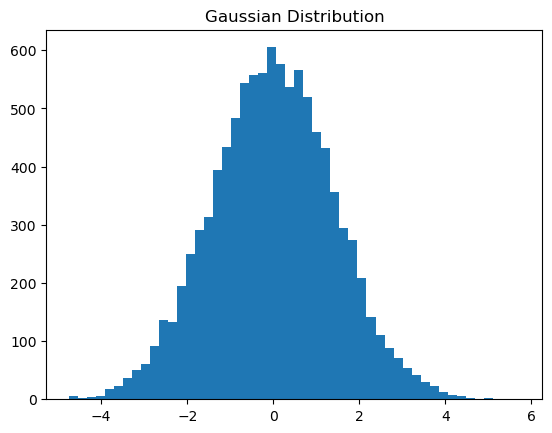

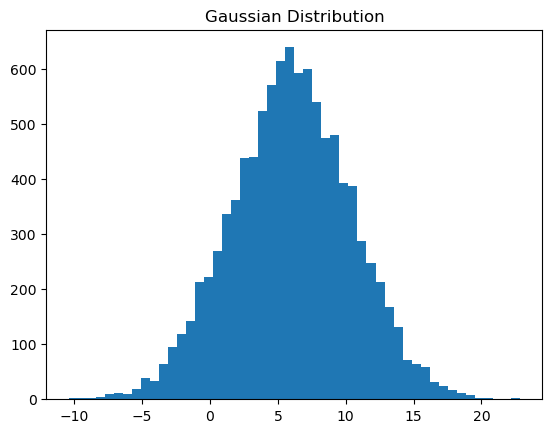

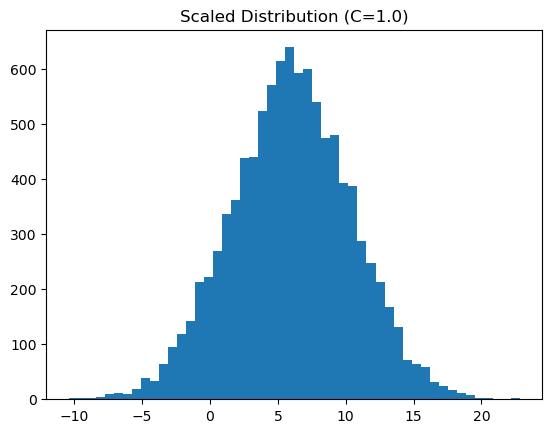

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = 0
sigma = 1.0
N = 10000
m = 50

def myFunc(x1, sigma1, x2, sigma2):
    myRandomArray1 = np.random.normal(x1, sigma1, N)
    myRandomArray2 = np.random.normal(x2, sigma2, N)
    myArray = myRandomArray1 + myRandomArray2
    plt.figure()
    plt.hist(myArray, m, histtype='stepfilled')
    plt.title("Gaussian Distribution")
    plt.savefig("myFunc.png")
    plt.show()
    
    return myArray  
myFunc(x, sigma, x, sigma)


def myFunc2(x1, x2, C):
    sigma_1 = np.abs(C * x1) 
    sigma_2 = np.abs(C * x2) 
    combined_array = myFunc(x1, sigma_1, x2, sigma_2)
    plt.figure()
    plt.hist(combined_array, bins=m, histtype='stepfilled')
    plt.title(f"Scaled Distribution (C={C})")
    plt.savefig("myFunc2.png")
    plt.show()
    return
   
myFunc2(x1=2.0, x2=4.0, C=1.0)

(c) Recall from your physics labs, when you make repeated measurements of a quantity, the measurements follow a Gaussian distribution, where the mean (hopefully) represents the 'true' value of the quantity and the standard deviation represents the statistical uncertainty (error) on the measurement. 
If you make repeated measurements of two different quantities, and use these two quantities to calculate a third quantity, the error propagates, so you have to use error propagation formulas to figure out the uncertainty on the third quantity.

Numerical errors in calculations propagate in a similar manner. We can represent the numerical error on stored value $x$ as $\sigma$, and define our fractional error constant as $C$ such that $\sigma = C |x|$. Plugging this into Part (b), we get $\sigma_1 = C |x_1|, \sigma_2 = C |x_2|$. 

Run your function in part (b) with: $N=10^6, C=10^{-7}, x_1 = 100, x_2 = -100$. (For the purposes of this exercise, we're using a value of $C$ that corresponds to 32-bit float precision rather than 64-bit, so that we can see its effect.) Now try again with different mean values: $x_1 = 1.0, x_2 = -1.0$

Hopefully, you now see visually why adding a positive number to a negative number, where both have large absolutely values, can produce large errors.

Running Experiment 1 (x1 = 100, x2 = -100)...


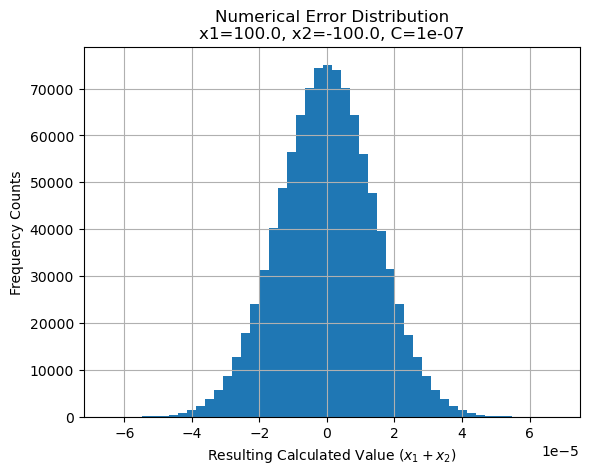

Running Experiment 2 (x1 = 1.0, x2 = -1.0)...


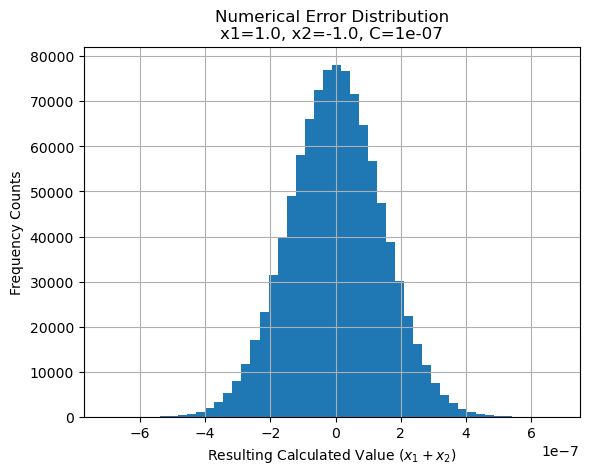

In [12]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000000  
m = 50
C_val = 1e-7

def myFunc(x1, sigma1, x2, sigma2):
    # Generates two random Gaussian datasets with specific means and errors
    myRandomArray1 = np.random.normal(x1, sigma1, N)
    myRandomArray2 = np.random.normal(x2, sigma2, N)
    myArray = myRandomArray1 + myRandomArray2
    return myArray  

def myFunc2(x1, x2, C):
    # Error propagation calculation: sigma = C * |x|
    sigma_1 = np.abs(C * x1) 
    sigma_2 = np.abs(C * x2) 
    
    combined_array = myFunc(x1, sigma_1, x2, sigma_2)
    
   
    plt.figure()
    plt.hist(combined_array, bins=m, histtype='stepfilled')
    plt.title(f"Numerical Error Distribution\nx1={x1}, x2={x2}, C={C}")
    plt.xlabel("Resulting Calculated Value ($x_1 + x_2$)")
    plt.ylabel("Frequency Counts")
    plt.grid(True)
    
    filename = f"error_dist_x1_{int(x1)}.png"
    plt.savefig("q2_c")
    plt.show()
    return

print("Running Experiment 1 (x1 = 100, x2 = -100)...")
myFunc2(x1=100.0, x2=-100.0, C=C_val)

print("Running Experiment 2 (x1 = 1.0, x2 = -1.0)...")
myFunc2(x1=1.0, x2=-1.0, C=C_val)


## 3. Trapezoidal Rule numerical integration

Evaluate the integral of $f(x) = x^4 - 2x^3 + 1$ on the interval $[0, 2]$: first symbolically, and then numerically using the trapezoidal rule.

Note, we can evaluate the integral symbolically as long as the function has an analytical expression that SymPy (or Maple, Mathematica, Wolfram Alpha...) knows how to solve. Otherwise, numerical integration is required.

In [13]:
from sympy import *

def f(x):
    return (x**4 - 2*x**3 + 1)

a = 0.0
b = 2.0

xs = Symbol('xs', real=True)
exact_area = integrate(f(xs), (xs, a, b))
print("Symbolic Exact Integral Result:", exact_area)



Symbolic Exact Integral Result: 0.400000000000000


In [14]:
from sympy import *

def f(x):
    return (x**4 - 2*x**3 + 1)

a = 0.0
b = 2.0

xs = Symbol('xs', real=True)
exact_area = integrate(f(xs), (xs, a, b))
print("Symbolic Exact Integral Result:", exact_area)

N = 100  
h = (b - a) / N

area = f(a) + f(b)

for i in range(1, N):
    x_i = a + i * h
    area += 2 * f(x_i)

numerical_area = (h / 2) * area

print(f"Numerical Integral Result (N={N}):", numerical_area)


Symbolic Exact Integral Result: 0.400000000000000
Numerical Integral Result (N=100): 0.4002666559999997
